In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


In [12]:
df = pd.read_excel('glass.xlsx', sheet_name='glass')
df.head()


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [13]:
print("Data shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Data types:\n", df.dtypes)


Data shape: (214, 10)
Columns: ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']
Data types:
 RI      float64
Na      float64
Mg      float64
Al      float64
Si      float64
K       float64
Ca      float64
Ba      float64
Fe      float64
Type      int64
dtype: object


In [14]:
# List feature columns (exclude 'Type' which is the target)
feature_cols = [col for col in df.columns if col != 'Type']

# Convert all features to numeric (coerce errors to NaN)
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='coerce')

# Confirm correct types
print(df.dtypes)


RI      float64
Na      float64
Mg      float64
Al      float64
Si      float64
K       float64
Ca      float64
Ba      float64
Fe      float64
Type      int64
dtype: object


Missing values per column:
 RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


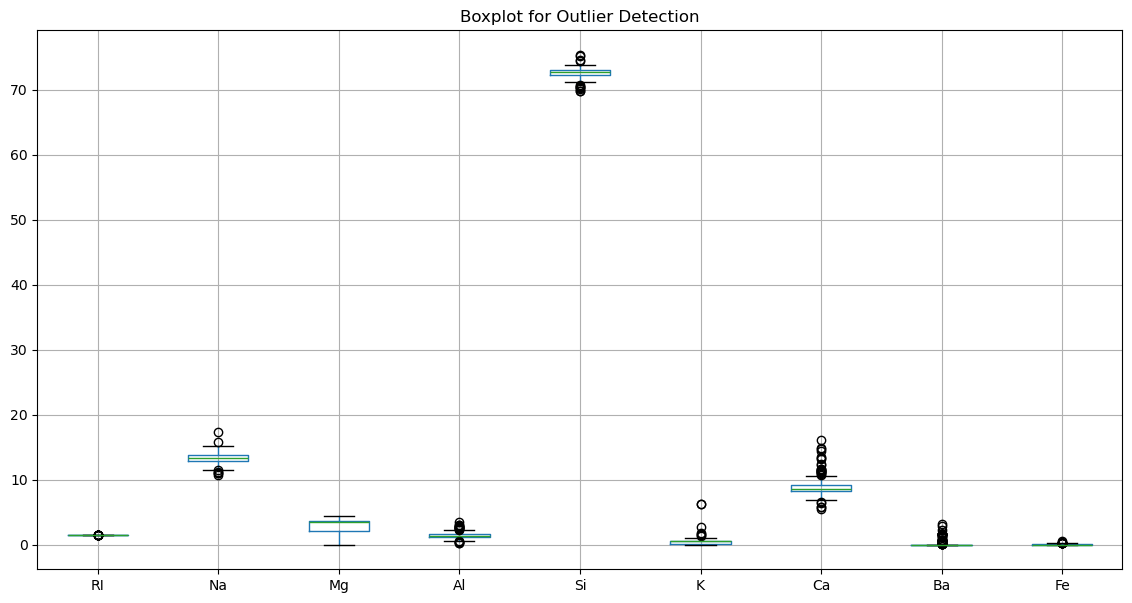

In [15]:
# Check missing values
print("Missing values per column:\n", df.isnull().sum())

# Boxplot of features (excluding target 'Type')
plt.figure(figsize=(14, 7))
df[feature_cols].boxplot()
plt.title("Boxplot for Outlier Detection")
plt.show()


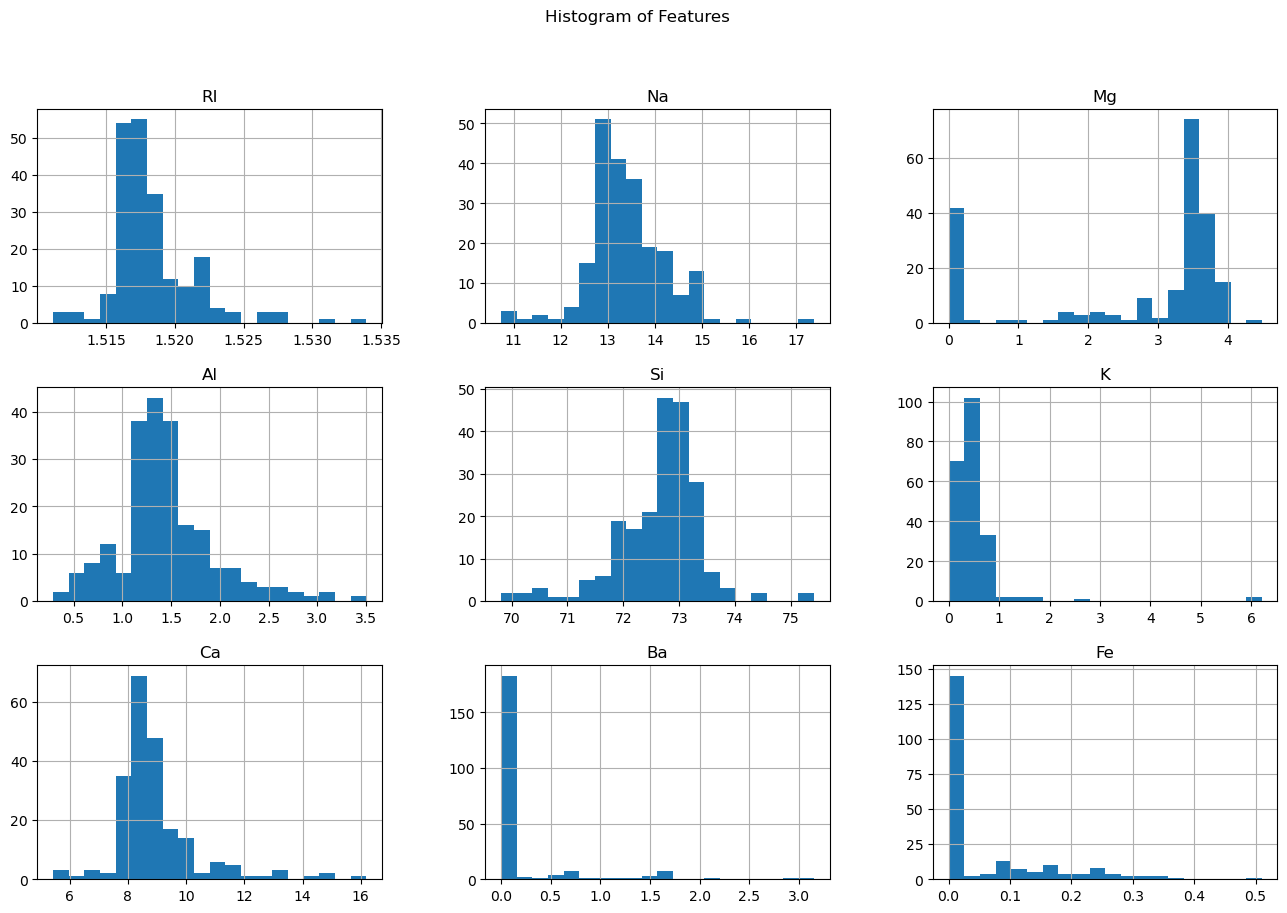

In [16]:
df[feature_cols].hist(figsize=(16, 10), bins=20)
plt.suptitle("Histogram of Features")
plt.show()


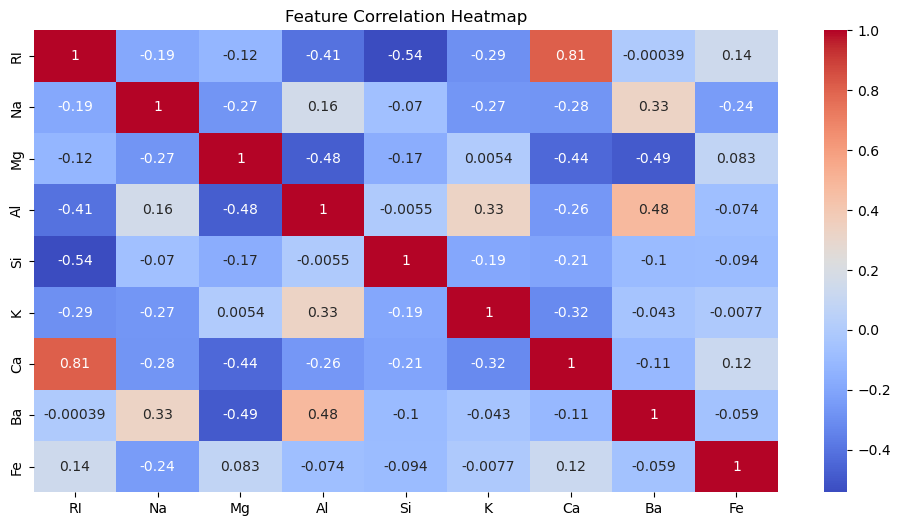

In [17]:
plt.figure(figsize=(12, 6))
sns.heatmap(df[feature_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


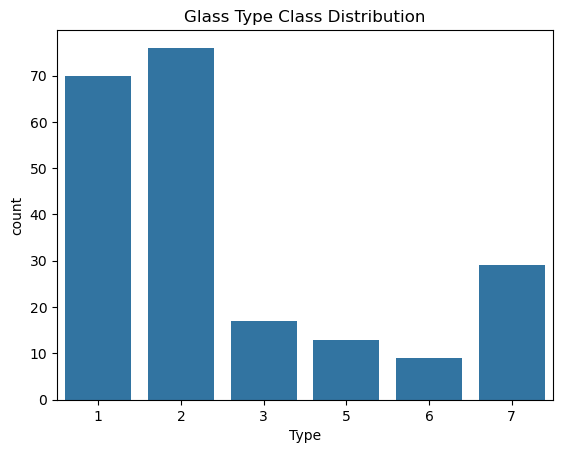

Class counts:
 Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64


In [18]:
sns.countplot(x='Type', data=df)
plt.title("Glass Type Class Distribution")
plt.show()

print("Class counts:\n", df['Type'].value_counts())


In [19]:
# If any missing, drop rows
df_clean = df.dropna()
print("Shape after dropping missing values:", df_clean.shape)


Shape after dropping missing values: (214, 10)


In [20]:
X = df_clean[feature_cols]
y = df_clean['Type']


In [21]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("Original class distribution:\n", y.value_counts())
print("After SMOTE:\n", pd.Series(y_res).value_counts())


Original class distribution:
 Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64
After SMOTE:
 Type
1    76
2    76
3    76
5    76
6    76
7    76
Name: count, dtype: int64


In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_res, test_size=0.3, random_state=42, stratify=y_res)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (319, 9)
Test shape: (137, 9)


In [24]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Random Forest Accuracy: 0.9124087591240876
              precision    recall  f1-score   support

           1       0.80      0.91      0.85        22
           2       0.94      0.70      0.80        23
           3       0.91      0.91      0.91        23
           5       0.96      0.96      0.96        23
           6       0.96      1.00      0.98        23
           7       0.92      1.00      0.96        23

    accuracy                           0.91       137
   macro avg       0.91      0.91      0.91       137
weighted avg       0.92      0.91      0.91       137

[[20  1  1  0  0  0]
 [ 3 16  1  1  1  1]
 [ 2  0 21  0  0  0]
 [ 0  0  0 22  0  1]
 [ 0  0  0  0 23  0]
 [ 0  0  0  0  0 23]]


In [26]:
# For scikit-learn >= 1.2
bagging = BaggingClassifier(estimator=RandomForestClassifier(), n_estimators=50, random_state=42)
bagging.fit(X_train, y_train)
y_bag = bagging.predict(X_test)

print("Bagging Accuracy:", accuracy_score(y_test, y_bag))
print(classification_report(y_test, y_bag))


Bagging Accuracy: 0.8832116788321168
              precision    recall  f1-score   support

           1       0.70      0.86      0.78        22
           2       0.94      0.70      0.80        23
           3       0.90      0.78      0.84        23
           5       0.92      0.96      0.94        23
           6       0.96      1.00      0.98        23
           7       0.92      1.00      0.96        23

    accuracy                           0.88       137
   macro avg       0.89      0.88      0.88       137
weighted avg       0.89      0.88      0.88       137



In [27]:
# For scikit-learn >= 1.2
adaboost = AdaBoostClassifier(estimator=RandomForestClassifier(), n_estimators=100, random_state=42)
adaboost.fit(X_train, y_train)
y_boost = adaboost.predict(X_test)

print("Boosting Accuracy:", accuracy_score(y_test, y_boost))
print(classification_report(y_test, y_boost))


Boosting Accuracy: 0.8832116788321168
              precision    recall  f1-score   support

           1       0.73      0.86      0.79        22
           2       0.88      0.65      0.75        23
           3       0.90      0.83      0.86        23
           5       0.92      0.96      0.94        23
           6       0.96      1.00      0.98        23
           7       0.92      1.00      0.96        23

    accuracy                           0.88       137
   macro avg       0.89      0.88      0.88       137
weighted avg       0.89      0.88      0.88       137



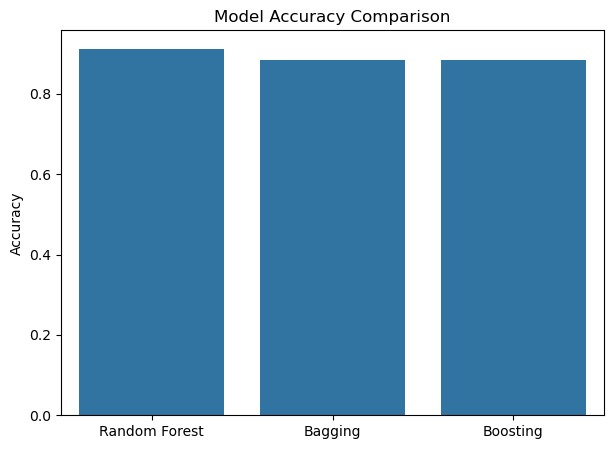

In [28]:
models = ["Random Forest", "Bagging", "Boosting"]
accuracies = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_bag),
    accuracy_score(y_test, y_boost)
]
plt.figure(figsize=(7, 5))
sns.barplot(x=models, y=accuracies)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()


###1. Bagging vs Boosting: Methods and Differences
Bagging (Bootstrap Aggregating):

Bagging stands for “Bootstrap Aggregating.” It involves training multiple base learners (often decision trees) independently using randomly sampled subsets (with replacement) of the data.

Each model is built in parallel, on slightly different versions of the data, and their predictions are averaged (for regression) or voted (for classification).

Bagging mostly reduces variance, helping prevent overfitting. Typical example: Random Forest.

Boosting:

Boosting trains base learners sequentially. Each new learner is trained to correct the errors of the previous one, often placing more weight on misclassified samples.

Weak learners are combined, with each having a different influence (weight) on the final prediction.

Boosting reduces both bias and variance, but is more prone to overfitting if not regularized properly. Examples: AdaBoost, Gradient Boosting, XGBoost.

Method	How Models are Built	Main Goal	Example Algorithms
Bagging	In parallel (independent)	Reduce variance	Random Forest
Boosting	Sequential (dependent)	Reduce bias & variance	AdaBoost, XGBoost
2. Handling Imbalanced Data
Imbalanced data occurs when some classes are under-represented compared to others, causing poor prediction performance on minority classes.

Common Handling Approaches:

Resampling:

Oversampling: Increases the minority class samples by duplicating or generating synthetic samples (e.g., SMOTE).

Undersampling: Reduces the majority class samples to balance the dataset.

Class weights:
Assign higher misclassification penalties to minority classes within the model (many classifiers support a class_weight parameter).

Algorithm choices:
Use algorithms designed for imbalanced data, or those less sensitive to imbalance (like tree-based ensembles).

Evaluation Metrics:
Use metrics suited for imbalanced data such as F1-score, recall, precision, ROC-AUC, rather than accuracy alone.

Example: In your Glass dataset, SMOTE is used to oversample minority glass types, ensuring the classifier sees enough examples from each class for learning robust decision boundaries.